In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Fonctions

In [ ]:
# Paramètres
f = 0.005 # 5mm
lambda_0 = 600e-9 # 600nm
nt = 1.0
k0 = (2 * np.pi)/(lambda_0)
kt = (2 * np.pi * nt) / lambda_0
R_pupille = 0.004 # 4mm
NA = R_pupille/f

# Grilles
N = 251
x = np.linspace(-R_pupille, R_pupille, N)
y = np.linspace(-R_pupille, R_pupille, N)
z = np.linspace(-100e-6, 100e-6, 2 * N)
z_micro = z * 1e6
X, Y = np.meshgrid(x, y)
Rp = np.sqrt(X**2 + Y**2)

# Fonctions
def compute_E(E_t, theta, z):
  # Calcule le champs après l'objectif du microscope
  A = -(1j * f)/(lambda_0 * kt**2)
  cos_theta = np.cos(theta)
  kz = kt * cos_theta

  E_apres = np.zeros((N, N, len(z)), dtype = complex)

  for i in range(len(z)):
    exp = f_exp(kz, z[i])

    E_3D = (E_t * exp) / cos_theta
    E_apres[:, :, i] = np.fft.fftshift(np.fft.fft2(E_3D))

  return A * E_apres

def theta_field(X, Y, R, NA):
  # Construit la grille des theta
  r = np.sqrt(X**2 + Y**2)
  a = (r/R) * (NA/nt)
  a = np.clip(a, 0, 1)
  return np.arcsin(a)

def f_exp(kz, z):
  return np.exp(1j * kz * z)

def Plot_output(field_phase): #Plot les graph apres etre passé dans l'objectif de microscope (plot les 3 coupes transversales)
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    mid = [s//2 for s in field_phase.shape]
    plt.suptitle('Coupes transversales')

    x_min, x_max = -R_pupille*1e3, R_pupille*1e3
    z_min, z_max = -100, 100

    axes[0].imshow(field_phase[mid[0], :, :], cmap='viridis', aspect='auto', extent=[z_min, z_max, x_max, x_min])
    axes[0].set_xlabel('z (µm)')
    axes[0].set_ylabel('y (mm)')
    axes[0].set_title('Coupe YZ')

    axes[1].imshow(field_phase[:, mid[1], :], cmap='viridis', aspect='auto', extent=[z_min, z_max, x_max, x_min])
    axes[1].set_xlabel('z (µm)')
    axes[1].set_ylabel('x (mm)')
    axes[1].set_title('Coupe XZ')

    axes[2].imshow(field_phase[:, :, mid[2]], cmap='viridis', aspect='equal', extent=[x_min, x_max, x_max, x_min])
    axes[2].set_xlabel('x (mm)')
    axes[2].set_ylabel('y (mm)')
    axes[2].set_title('Coupe XY')

    plt.tight_layout()
    plt.show()


def Plot_input(E_t): # Plot l'amplitude et la phase de l'image dans la pupille d'entré
    Et_ampl = np.abs(E_t)
    Et_arg = np.angle(E_t)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    plt.suptitle('Champ en entrée')

    x_min, x_max = -R_pupille*1e3, R_pupille*1e3

    axes[0].imshow(Et_ampl, cmap='viridis', aspect='equal', extent=[x_min, x_max, x_max, x_min])
    axes[0].set_xlabel('x (mm)')
    axes[0].set_ylabel('y (mm)')
    axes[0].set_title('Amplitude du champ')

    axes[1].imshow(Et_arg, cmap='viridis', aspect='equal', extent=[x_min, x_max, x_max, x_min])
    axes[1].set_xlabel('x (mm)')
    axes[1].set_ylabel('y (mm)')
    axes[1].set_title('Phase du champ')

    plt.tight_layout()
    plt.show()

theta = theta_field(X, Y, R_pupille, NA) # Grille des theta

def Plotfaisceau(E_apres):
  # Récupère les indices du tableau 3D des bords du faisceau
  field = np.abs(E_apres)
  mid = [s//2 for s in field.shape]
  upper_yz = np.zeros(len(z))
  lower_yz = np.zeros(len(z))

  for i in range(len(z)): # Dans le plan yz
    idx_max = N
    idx_min = 0
    seuil = (1/2) * np.max(field[mid[0], :, i]) # Seuil par rapport au pixel d'intensité max de la colonne

    for j in range(len(y)): # Recherche du pixel de la partie supérieur du faisceau
      if (field[mid[0], len(y) - j - 1, i] > seuil):
        idx_max = len(y) - j - 1
        break

    for j in range(len(y)): # Recherche du pixel de la partie inferieur du faisceau
      if (field[mid[0], j, i] > seuil):
        idx_min = j
        break

    upper_yz[i] = idx_max
    lower_yz[i] = idx_min

  return upper_yz, lower_yz # Ne renvoie que pour l'un des plan car symétrie par rotation autour de l'axe z

# Faisceau Gaussien

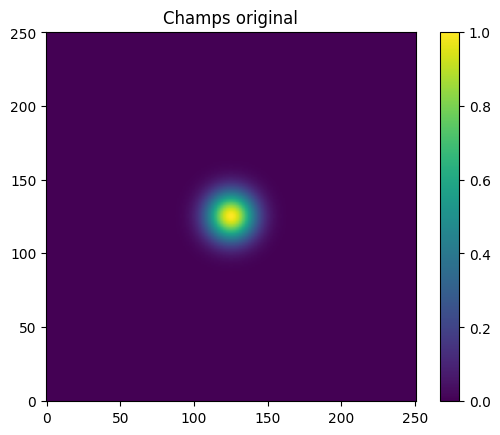

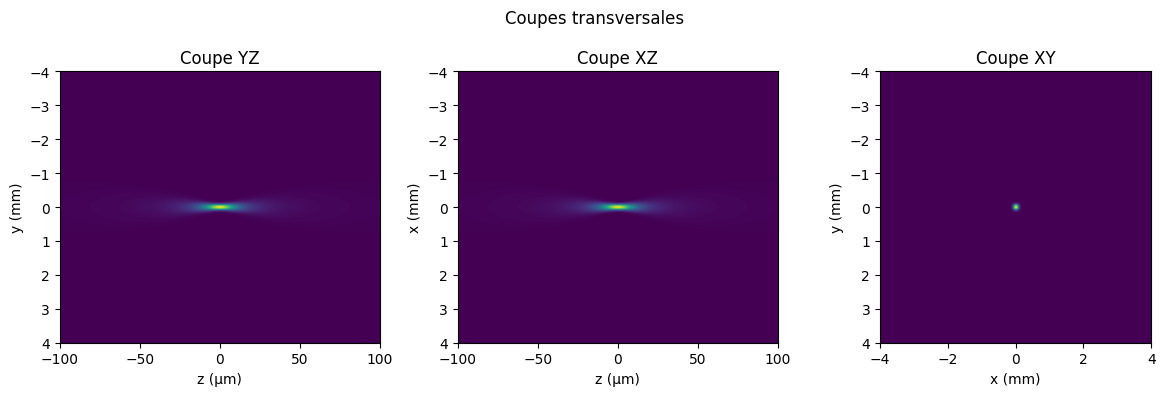

Text(0.5, 1.0, 'Phase du champs au centre du champs')

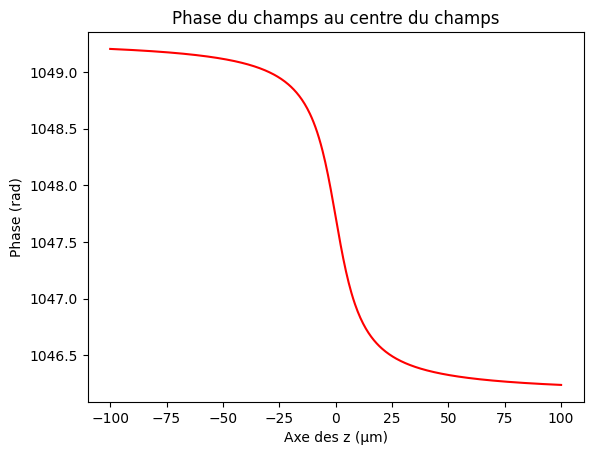

In [ ]:
# le faisceau Gaussien subit un déphasage de pi entre -l'infini et +l'infini, centré au plan focale image
# Le nom est la phase de Gouy, elle est defini comme le retard(ou l'avance) de phase d'un faisceau focalisé par rapport à une onde plane qui se propage dans le vide (phase en k0 * z)
beta = 30
Et1_gausse = np.exp(-beta * (Rp/R_pupille)**2) # Champs gaussien avant la pupille
Et1_gausse[Rp > R_pupille] = 0 # Champs restreint à la pupille

E1_gausse = compute_E(Et1_gausse, theta, z) # Champs après le système optique

# Plot du champs original sans phase quadratique
plt.figure()
plt.imshow(np.abs(Et1_gausse)**2, cmap='viridis', origin='lower')
plt.title('Champs original')
plt.colorbar()

# Plot du champs après sans phase quadratique
Plot_output(np.abs(E1_gausse)**2)

# Plot de la phase en z=0
mid = [s//2 for s in E1_gausse.shape]
# np.angle fait des saut pour la phase en passant de -pi à pi, np.unwrap enlève cette discontinuité en rajoutant/enlevent 2 * pi
phase = np.unwrap(np.angle(E1_gausse[mid[0], mid[1], :]) - (k0 * z))

plt.figure()
plt.plot(z_micro, phase, color = 'red')
plt.xlabel('Axe des z (μm)')
plt.ylabel('Phase (rad)')
plt.title('Phase du champs au centre du champs')

# Faisceau Gaussien avec ou sans phase quadratique (défocalisation)

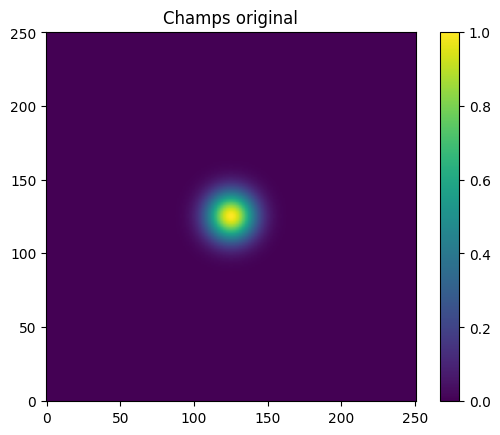

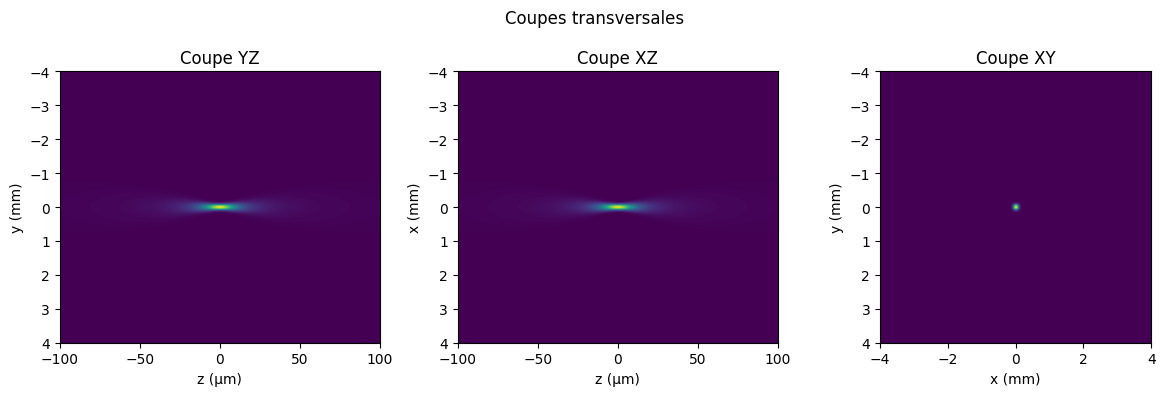

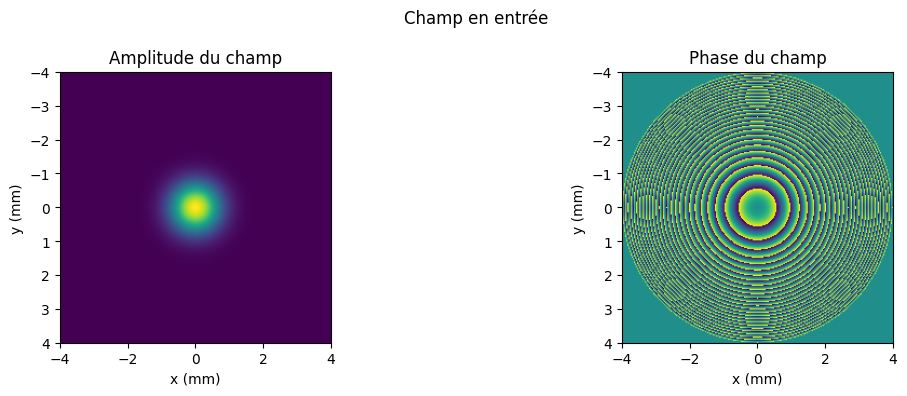

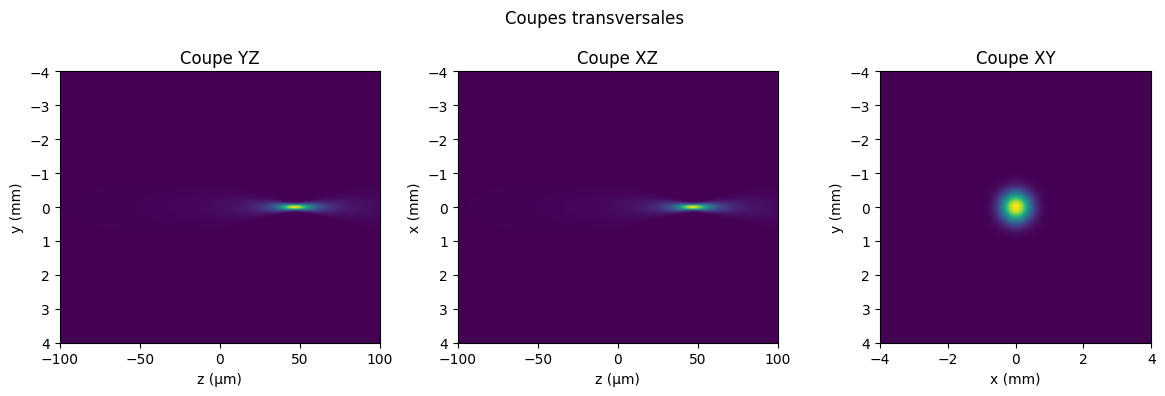

In [ ]:
# En ajoutant une phase quadratique, on observe une defocalisation du faisceau
alpha = 1e7
exp_phase = np.exp(1j * alpha * (X**2 + Y**2))

Et_gausse = np.exp(-beta * (Rp/R_pupille)**2) # Champs gaussien avant la pupille
Et_gausse_phase = np.exp(-beta * (Rp/R_pupille)**2) * exp_phase
Et_gausse[Rp > R_pupille] = 0 # Champs restreint à la pupille
Et_gausse_phase[Rp > R_pupille] = 0 # Champs restreint à la pupille

E_gausse = compute_E(Et_gausse, theta, z) # Champs après le système optique
E_gausse_phase = compute_E(Et_gausse_phase, theta, z) # Champs après le système optique avec phase quadratique

# Plot du champs original sans phase quadratique
plt.figure()
plt.imshow(np.abs(Et_gausse)**2, cmap='viridis', origin='lower')
plt.title('Champs original')
plt.colorbar()

# Plot du champs après sans phase quadratique
Plot_output(np.abs(E_gausse)**2)

# Plot du champs original avec phase quadratique
Plot_input(Et_gausse_phase)

# Plot du champs après avec phase quadratique
Plot_output(np.abs(E_gausse_phase)**2)


# Faisceau de Bessel

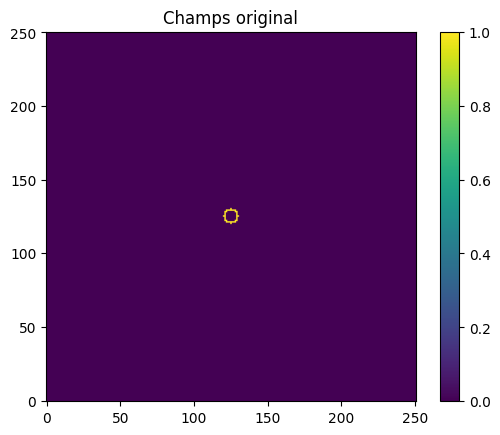

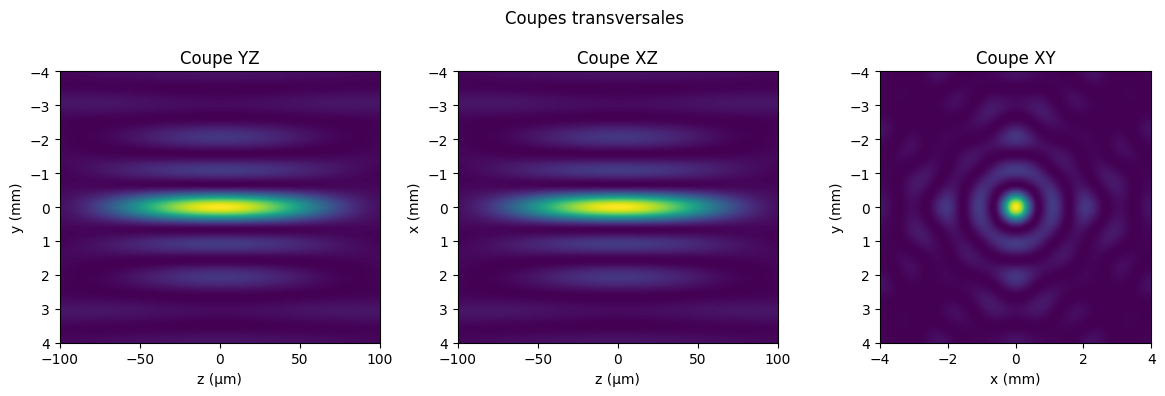

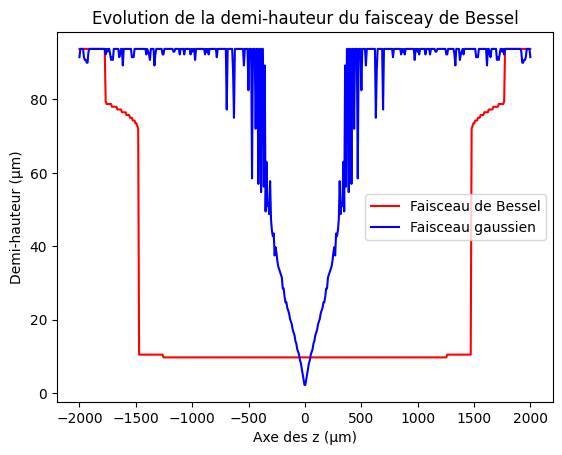

In [ ]:
# Faisceau de Bessel

# Paramètres
z = np.linspace(-2000e-6, 2000e-6, 500)
z_micro = z * 1e6
Et_Bessel = np.zeros((N, N)) # Anneau
center_x = N//2
center_y = N//2
radius_inf = (0.5 * N)//30
radius_sup = (0.6 * N)//30

for xi in range(N):
  for yi in range(N):
    if (((np.sqrt((center_x - xi)**2 + (center_y - yi)**2)) >= radius_inf) & ((np.sqrt((center_x - xi)**2 + (center_y - yi)**2) <= radius_sup))):
      Et_Bessel[xi, yi] = 1

E_Bessel = compute_E(Et_Bessel, theta, z) # Champs après du cercle

# Plot du champs original
plt.figure()
plt.imshow(Et_Bessel, cmap='viridis', origin='lower')
plt.title('Champs original')
plt.colorbar()

# Plot du champs après
Plot_output(np.abs(E_Bessel)**2)


# Faisceau Gaussien

Et_gausse = np.exp(-10 * (Rp/R_pupille)) # Champs gaussien avant la pupille
Et_gausse[Rp > R_pupille] = 0 # Champs restreint à la pupille

E_gausse = compute_E(Et_gausse, theta, z) # Champs après l'objectif


# Vérification que le faisceau de Bessel ideal (plus l'anneau est fin, plus il est ideal) diverge très peu par rapport au faisceau gaussien
# Pour verifier sur de plus grande distance, il faut reduire la taille de l'anneau et donc augmenter le nombre de pixels (sinon on n'a plus un anneau)
# On observe le meme comportement lorsque l'on reduit le rayon de l'anneau
B_upper_yz, B_lower_yz = Plotfaisceau(E_Bessel)
G_upper_yz, G_lower_yz = Plotfaisceau(E_gausse)

pixel_size = (lambda_0 * f) / (2 * R_pupille)

demi_hauteur_B = (B_upper_yz - B_lower_yz) * pixel_size * 1e6
demi_hauteur_G = (G_upper_yz - G_lower_yz) * pixel_size * 1e6

plt.figure()
plt.plot(z_micro, demi_hauteur_B, color = 'red')
plt.plot(z_micro, demi_hauteur_G, color = 'blue')
plt.xlabel('Axe des z (μm)')
plt.ylabel('Demi-hauteur (μm)')
plt.legend(['Faisceau de Bessel', 'Faisceau gaussien'])
plt.title('Evolution de la demi-hauteur du faisceay de Bessel')
plt.show()


# Faisceau d'Airy

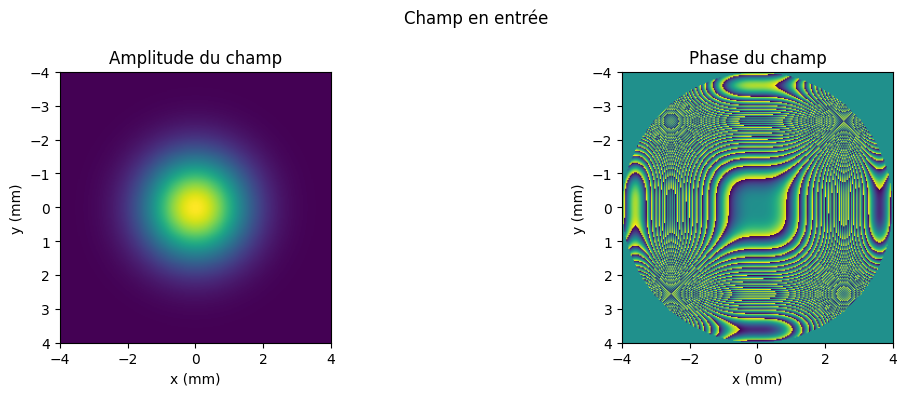

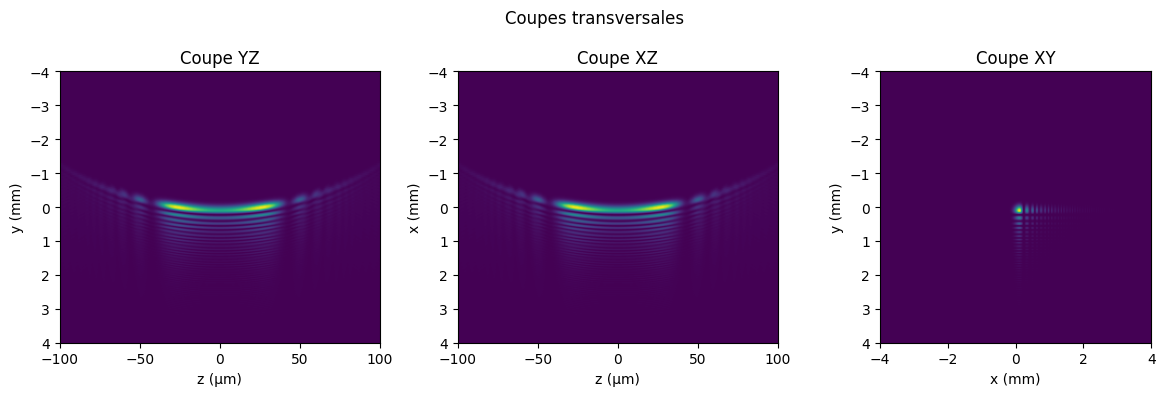

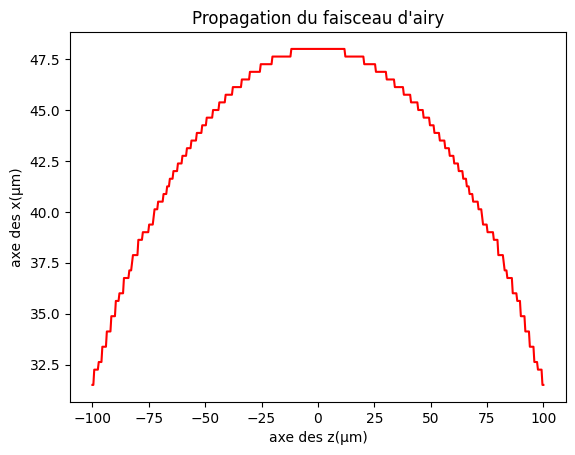

In [ ]:
# Paramètres
z = np.linspace(-100e-6, 100e-6, 2 * N)
z_micro = z * 1e6
gamma = 7

# Calcule du champs
alpha = 5e9
exp_phase = np.exp(1j * alpha * (X**3 + Y**3))

Et_airy = np.exp(-gamma * (Rp/R_pupille)**2) * exp_phase # Champs dans la pupille
Et_airy[Rp > R_pupille] = 0 # Champs restreint à la pupille

E_airy = compute_E(Et_airy, theta, z) # Champs après sans phase quadratique

# Plot du champs original
Plot_input(Et_airy)

# Plot du champs après
Plot_output(np.abs(E_airy)**2)

# Propagation du faisceau
max_intensity = []
for i in range(len(z)):
  max_idx_flat = np.argmax(np.abs(E_airy[:, :, i]))
  row, col = np.unravel_index(max_idx_flat, E_airy[:, :, i].shape)
  max_intensity.append((row, col))

max_intensity = np.array(max_intensity)

# Plot de la propagation du faisceau (Ce faisceau à la particularité de ce propagé selon une courbe parabolique)
z_micro = z*1e6
plt.figure()
plt.plot(z_micro, (max_intensity[:, 1] * pixel_size) * 1e6, color = 'red')
plt.xlabel('axe des z(μm)')
plt.ylabel("axe des x(μm)")
plt.title("Propagation du faisceau d'airy")
plt.show()